In [22]:
import pandas as pd
from fetch_data.config import config
import numpy as np
import os
import matplotlib.pyplot as plt

# Carregar os dados

In [2]:
df_ecommerce = pd.read_csv(os.path.join(config.DATA_PROCESSED, 'data_ecommerce.csv'))
df_mkt_funnel = pd.read_csv(os.path.join(config.DATA_PROCESSED, 'data_mkt_funnel.csv'))

In [4]:
df_ecommerce.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,...,seller_city,seller_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,...,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,...,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,...,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,128e10d95713541c87cd1a2e48201934,a20e8105f23924cd00833fd87daa0831,delivered,2017-08-15 18:29:31,2017-08-15 20:05:16,2017-08-17 15:28:33,2017-08-18 14:44:43,2017-08-28 00:00:00,1,credit_card,...,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
4,0e7e841ddf8f8f2de2bad69267ecfbcf,26c7ac168e1433912a51b924fbd34d34,delivered,2017-08-02 18:24:47,2017-08-02 18:43:15,2017-08-04 17:35:43,2017-08-07 18:30:01,2017-08-15 00:00:00,1,credit_card,...,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0


In [5]:
df_mkt_funnel.head()

,mql_id,first_contact_date,landing_page_id,origin,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,...,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue,order_id,order_item_id,product_id,shipping_limit_date,price,freight_value
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,...,NaN,reseller,NaN,0.0,1efcc6ba75b519535a510c53153a9256,1.0,e94df75b2e9a8b056be0c144a731f55c,2018-06-26 22:20:21,94.2,18.76


In [7]:
df_ecommerce.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'seller_zip_code_prefix', 'seller_city',
       'seller_state', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [8]:
df_mkt_funnel.columns

Index(['mql_id', 'first_contact_date', 'landing_page_id', 'origin',
       'seller_id', 'sdr_id', 'sr_id', 'won_date', 'business_segment',
       'lead_type', 'lead_behaviour_profile', 'has_company', 'has_gtin',
       'average_stock', 'business_type', 'declared_product_catalog_size',
       'declared_monthly_revenue', 'order_id', 'order_item_id', 'product_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

# Datasets infos

In [9]:
df_ecommerce.shape

(118315, 39)

In [10]:
df_mkt_funnel.shape

(12664, 23)

### Descriptive Statistics

In [14]:
df_ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118315 entries, 0 to 118314
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118315 non-null  object 
 1   customer_id                    118315 non-null  object 
 2   order_status                   118315 non-null  object 
 3   order_purchase_timestamp       118315 non-null  object 
 4   order_approved_at              118300 non-null  object 
 5   order_delivered_carrier_date   117061 non-null  object 
 6   order_delivered_customer_date  115727 non-null  object 
 7   order_estimated_delivery_date  118315 non-null  object 
 8   payment_sequential             118315 non-null  int64  
 9   payment_type                   118315 non-null  object 
 10  payment_installments           118315 non-null  int64  
 11  payment_value                  118315 non-null  float64
 12  review_id                     

In [16]:
df_ecommerce.describe().T

,count,mean,std,min,25%,50%,75%,max
payment_sequential,118315.0,1.094062,0.728555,1.00,1.00,1.00,1.00,29.00
payment_installments,118315.0,2.943498,2.778022,0.00,1.00,2.00,4.00,24.00
payment_value,118315.0,172.575651,267.104661,0.00,60.85,108.20,189.26,13664.08
review_score,118315.0,4.014554,1.400186,1.00,3.00,5.00,5.00,5.00
customer_zip_code_prefix,118315.0,35051.681579,29824.811223,1003.00,11310.00,24310.00,58640.00,99990.00
order_item_id,118315.0,1.196509,0.699452,1.00,1.00,1.00,1.00,21.00
price,118315.0,120.651027,184.109626,0.85,39.90,74.90,134.90,6735.00
freight_value,118315.0,20.033024,15.836523,0.00,13.08,16.28,21.18,409.68
seller_zip_code_prefix,118315.0,24440.790703,27571.679456,1001.00,6429.00,13660.00,27946.50,99730.00
product_name_lenght,116606.0,48.767782,10.033375,5.00,42.00,52.00,57.00,76.00


In [15]:
df_mkt_funnel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12664 entries, 0 to 12663
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   mql_id                         12664 non-null  object 
 1   first_contact_date             12664 non-null  object 
 2   landing_page_id                12664 non-null  object 
 3   origin                         12597 non-null  object 
 4   seller_id                      5506 non-null   object 
 5   sdr_id                         5506 non-null   object 
 6   sr_id                          5506 non-null   object 
 7   won_date                       5506 non-null   object 
 8   business_segment               5505 non-null   object 
 9   lead_type                      5455 non-null   object 
 10  lead_behaviour_profile         3679 non-null   object 
 11  has_company                    88 non-null     object 
 12  has_gtin                       89 non-null    

In [17]:
df_mkt_funnel.describe().T

,count,mean,std,min,25%,50%,75%,max
declared_product_catalog_size,69.0,233.028986,352.380558,1.0,30.0000,100.000,300.00,2000.00
declared_monthly_revenue,5506.0,11221.214312,682480.502851,0.0,0.0000,0.000,0.00,50000000.00
order_item_id,5044.0,1.170896,0.575577,1.0,1.0000,1.000,1.00,7.00
price,5044.0,134.189429,211.746414,2.2,43.8625,93.995,139.00,3899.00
freight_value,5044.0,19.620172,19.133071,0.0,12.2400,16.510,20.44,306.06


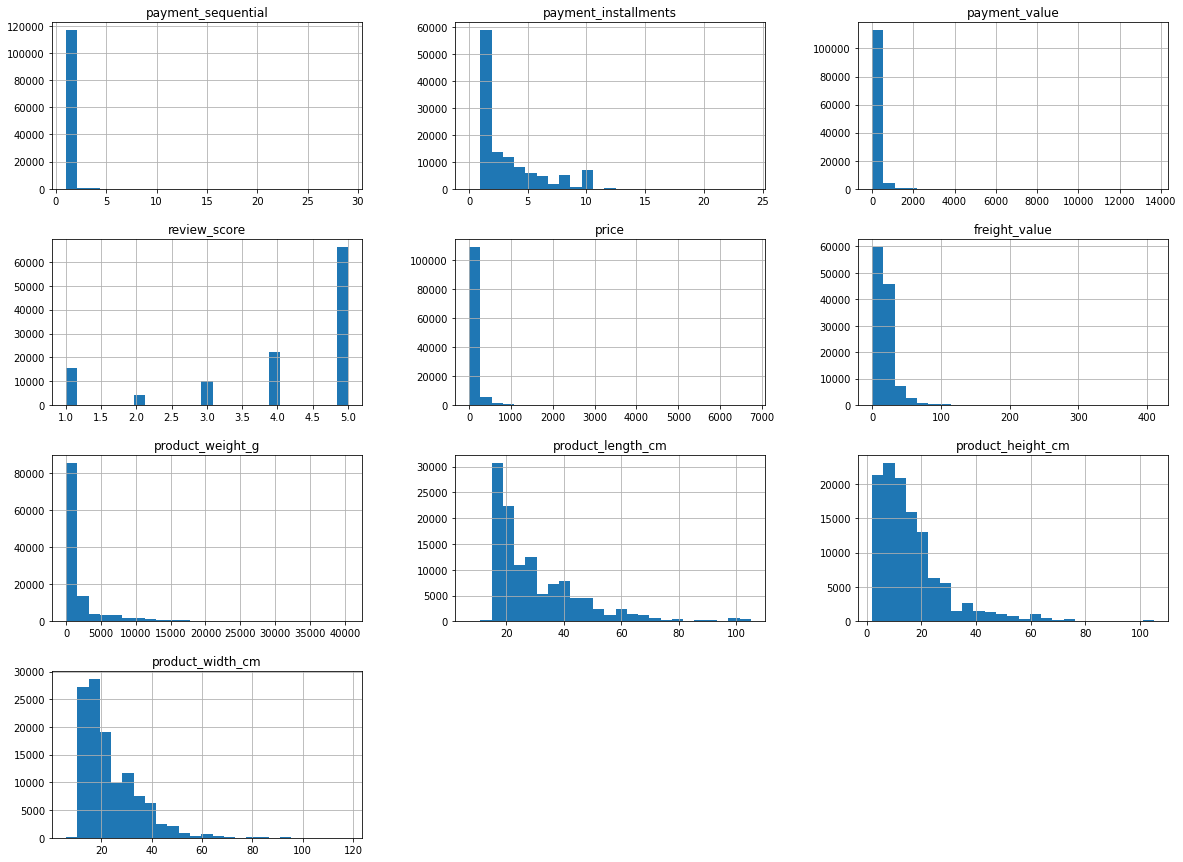

In [25]:
df_ecommerce[['payment_sequential', 'payment_installments', 'payment_value' ,'review_score', 'price', 'freight_value', 'product_weight_g' , 'product_length_cm' , 'product_height_cm' , 'product_width_cm']].hist( bins=25, figsize=(20,15) );

In [27]:
df_ecommerce[['order_status', 'payment_type', 'customer_city', 'customer_state', 'seller_city', 'seller_state', 'product_category_name']].describe()

,order_status,payment_type,customer_city,customer_state,seller_city,seller_state,product_category_name
count,118315,118315,118315,118315,118315,118315,116606
unique,7,4,4110,27,611,23,73
top,delivered,credit_card,sao paulo,SP,sao paulo,SP,cama_mesa_banho
freq,115728,87266,18728,49865,29294,84384,11990


In [30]:
df_mkt_funnel[['origin', 'business_segment', 'business_type', 'lead_type', 'lead_behaviour_profile', 'has_company', 'has_gtin']].describe()

,origin,business_segment,business_type,lead_type,lead_behaviour_profile,has_company,has_gtin
count,12597,5505,5494,5455,3679,88,89
unique,10,33,3,8,9,2,2
top,organic_search,health_beauty,reseller,online_medium,cat,True,True
freq,3529,869,4662,2148,2152,59,79


In [29]:
df_mkt_funnel.head().T

,0,1,2,3,4
mql_id,dac32acd4db4c29c230538b72f8dd87d,8c18d1de7f67e60dbd64e3c07d7e9d5d,b4bc852d233dfefc5131f593b538befa,6be030b81c75970747525b843c1ef4f8,5420aad7fec3549a85876ba1c529bd84
first_contact_date,2018-02-01,2017-10-20,2018-03-22,2018-01-22,2018-02-21
landing_page_id,88740e65d5d6b056e0cda098e1ea6313,007f9098284a86ee80ddeb25d53e0af8,a7982125ff7aa3b2054c6e44f9d28522,d45d558f0daeecf3cccdffe3c59684aa,b48ec5f3b04e9068441002a19df93c6c
origin,social,paid_search,organic_search,email,organic_search
seller_id,NaN,NaN,NaN,NaN,2c43fb513632d29b3b58df74816f1b06
sdr_id,NaN,NaN,NaN,NaN,a8387c01a09e99ce014107505b92388c
sr_id,NaN,NaN,NaN,NaN,4ef15afb4b2723d8f3d81e51ec7afefe
won_date,NaN,NaN,NaN,NaN,2018-02-26 19:58:54
business_segment,NaN,NaN,NaN,NaN,pet
lead_type,NaN,NaN,NaN,NaN,online_medium


# Data cleaning

In [ ]:
df.isnull().sum()

In [ ]:
df.drop(['review_comment_title', 'review_comment_message'], axis = 1, inplace = True)

In [ ]:
df.dropna(inplace = True)

In [ ]:
df.shape

# Hipoteses
- Clientes que não tiveram as suas entregas feita na hora não voltam a comprar
- Clientes de SP são os que tenho o maior volume de compra
- Clientes que compram com cartão de crédito compra mais que do que aqueles que compram com boleto
- Clientes que compram produtos leves compram em maior quantidade
- Clientes que tiveram as suas compras canceladas não voltam a comprar
- Clientes que um alto valor de frete compram diversos produtos
- Categoria do produto mais vendido é aquela relacionada a eletrônicos
- Somente 30% das categorias do produto representam 80% da receita da empresa (levando em consideração uma taxa de 15% por cada venda)
- Produtos que passaram do limite de envio são pouco vendido
- Vendedores de SP são os que mais atrasam os envios 
- Os tops vendedores representam a maioria dos produtos vendidos

In [ ]:
df.product_category_name.unique()